In [1]:
import warnings
from tqdm import TqdmExperimentalWarning

warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

from src import constants as cnsts 
from src.statsforecastlab import StatsForecastLab

In [2]:
from src.utils import process_data

df = process_data(test=True)[0]
df

,unique_id,ds,y
0,HUFL,2016-07-01 00:00:00,5.82700
1,HUFL,2016-07-01 01:00:00,5.69300
2,HUFL,2016-07-01 02:00:00,5.15700
3,HUFL,2016-07-01 03:00:00,5.09000
4,HUFL,2016-07-01 04:00:00,5.35800
...,...,...,...
243875,OT.1,2018-06-26 15:00:00,6.05272
243876,OT.1,2018-06-26 16:00:00,6.05272
243877,OT.1,2018-06-26 17:00:00,6.05272
243878,OT.1,2018-06-26 18:00:00,6.05272


In [3]:
df2 = process_data()[0]
df2

,unique_id,ds,y
0,HUFL,2016-07-01 00:00:00,5.82700
1,HUFL,2016-07-01 01:00:00,5.69300
2,HUFL,2016-07-01 02:00:00,5.15700
3,HUFL,2016-07-01 03:00:00,5.09000
4,HUFL,2016-07-01 04:00:00,5.35800
...,...,...,...
243875,OT.1,2018-06-26 15:00:00,6.05272
243876,OT.1,2018-06-26 16:00:00,6.05272
243877,OT.1,2018-06-26 17:00:00,6.05272
243878,OT.1,2018-06-26 18:00:00,6.05272


In [2]:
sflab = StatsForecastLab(
    freq="h",
    normalization=True,
    test=False
)

In [21]:
_df_cv_results = sflab.best_results_metric_dataframe(
    metric="mae",
    result="crossval",
    unique_ids=cnsts.JCUIds
)
_df_cv_results

,metric,unique_id,metric_value,best_model,transformation
0,mae,HUFL,0.088415,AutoETS_sl24,identity
1,mae,HULL,0.066790,AutoETS_sl24,identity
2,mae,LUFL,0.088679,AutoARIMA_sl24,identity
3,mae,MUFL,0.092515,AutoETS_sl24,identity


In [22]:
_df_cv_results.loc[[1, 3], 'transformation'] = 'log'
df_cv_results = _df_cv_results.copy()
df_cv_results   

,metric,unique_id,metric_value,best_model,transformation
0,mae,HUFL,0.088415,AutoETS_sl24,identity
1,mae,HULL,0.066790,AutoETS_sl24,log
2,mae,LUFL,0.088679,AutoARIMA_sl24,identity
3,mae,MUFL,0.092515,AutoETS_sl24,log


In [23]:
groups = df_cv_results.groupby(["best_model", "transformation"], sort=False)

In [24]:
from src import grid_search_parameters as gsp
models = gsp.MODELS

In [29]:
for (best_model, transformation), group_df in groups:

    unique_ids_in_group = group_df["unique_id"].tolist()

    # # Resolve the model object matching best_model name
    # model_obj = next(
    #     (m for m in models if m.alias == best_model), None
    # )
    
    # if model_obj is None:
    #     raise ValueError(
    #         f"Model '{best_model}' found in CV results but not in models. "
    #         f"Available: {[m.alias for m in models]}"
    #     )
    
    print(unique_ids_in_group, best_model, transformation)

['HUFL'] AutoETS_sl24 identity
['HULL', 'MUFL'] AutoETS_sl24 log
['LUFL'] AutoARIMA_sl24 identity


In [3]:
sflab.predict()

File already exists at c:\Users\giust\projects\volatility-forecasting-master\Nixtla\StatsForecast\results_norm\horizon=72\best_forecast.csv, skipping computation.


In [4]:
from pathlib import Path
import pandas as pd

output_path = Path(cnsts.CSV_FOLDER_NORM / f"horizon=72" / "best_forecast.csv")
metric_df = pd.read_csv(output_path)   
metric_df


,unique_id,ds,prediction
0,HUFL,2018-05-26 19:00:00,0.332742
1,HUFL,2018-05-26 20:00:00,0.350948
2,HUFL,2018-05-26 21:00:00,0.374634
3,HUFL,2018-05-26 22:00:00,0.377123
4,HUFL,2018-05-26 23:00:00,0.509604
...,...,...,...
283,LUFL,2018-05-29 14:00:00,0.394025
284,LUFL,2018-05-29 15:00:00,0.397558
285,LUFL,2018-05-29 16:00:00,0.396319
286,LUFL,2018-05-29 17:00:00,0.407355


In [5]:
sflab.best_results_prediction_dataframe()

,unique_id,ds,cutoff,value,prediction
0,HUFL,2018-05-17 19:00:00,2018-05-17 18:00:00,0.410760,0.339811
1,HUFL,2018-05-17 20:00:00,2018-05-17 18:00:00,0.470267,0.384750
2,HUFL,2018-05-17 21:00:00,2018-05-17 18:00:00,0.475935,0.418005
3,HUFL,2018-05-17 22:00:00,2018-05-17 18:00:00,0.439097,0.437037
4,HUFL,2018-05-17 23:00:00,2018-05-17 18:00:00,0.526899,0.589285
...,...,...,...,...,...
3019,OT.1,2018-05-26 14:00:00,2018-05-23 18:00:00,0.555064,0.516133
3020,OT.1,2018-05-26 15:00:00,2018-05-23 18:00:00,0.566265,0.516133
3021,OT.1,2018-05-26 16:00:00,2018-05-23 18:00:00,0.566265,0.516133
3022,OT.1,2018-05-26 17:00:00,2018-05-23 18:00:00,0.566265,0.516133


In [4]:
sflab.predict()

Currently running: [72, 'identity', 'Naive']
Currently running: [72, 'identity', 'ARIMA']
Currently running: [72, 'identity', 'ARIMA_sl24']
Currently running: [72, 'identity', 'AutoARIMA']
Currently running: [72, 'identity', 'AutoARIMA_sl24']
Currently running: [72, 'identity', 'AutoETS']
Currently running: [72, 'identity', 'AutoETS_sl24']
Currently running: [48, 'identity', 'Naive']
Currently running: [48, 'identity', 'ARIMA']
Currently running: [48, 'identity', 'ARIMA_sl24']
Currently running: [48, 'identity', 'AutoARIMA']
Currently running: [48, 'identity', 'AutoARIMA_sl24']
Currently running: [48, 'identity', 'AutoETS']
Currently running: [48, 'identity', 'AutoETS_sl24']
Currently running: [24, 'identity', 'Naive']
Currently running: [24, 'identity', 'ARIMA']
Currently running: [24, 'identity', 'ARIMA_sl24']
Currently running: [24, 'identity', 'AutoARIMA']
Currently running: [24, 'identity', 'AutoARIMA_sl24']
Currently running: [24, 'identity', 'AutoETS']
Currently running: [24, 'i

In [5]:
sflab.cross_validation()

Currently running: [72, 'identity', 'Naive']
Currently running: [72, 'identity', 'ARIMA']
Currently running: [72, 'identity', 'ARIMA_sl24']
Currently running: [72, 'identity', 'AutoARIMA']
Currently running: [72, 'identity', 'AutoARIMA_sl24']
Currently running: [72, 'identity', 'AutoETS']
Currently running: [72, 'identity', 'AutoETS_sl24']
Currently running: [48, 'identity', 'Naive']
Currently running: [48, 'identity', 'ARIMA']
Currently running: [48, 'identity', 'ARIMA_sl24']
Currently running: [48, 'identity', 'AutoARIMA']
Currently running: [48, 'identity', 'AutoARIMA_sl24']
Currently running: [48, 'identity', 'AutoETS']
Currently running: [48, 'identity', 'AutoETS_sl24']
Currently running: [24, 'identity', 'Naive']
Currently running: [24, 'identity', 'ARIMA']
Currently running: [24, 'identity', 'ARIMA_sl24']
Currently running: [24, 'identity', 'AutoARIMA']
Currently running: [24, 'identity', 'AutoARIMA_sl24']
Currently running: [24, 'identity', 'AutoETS']
Currently running: [24, 'i

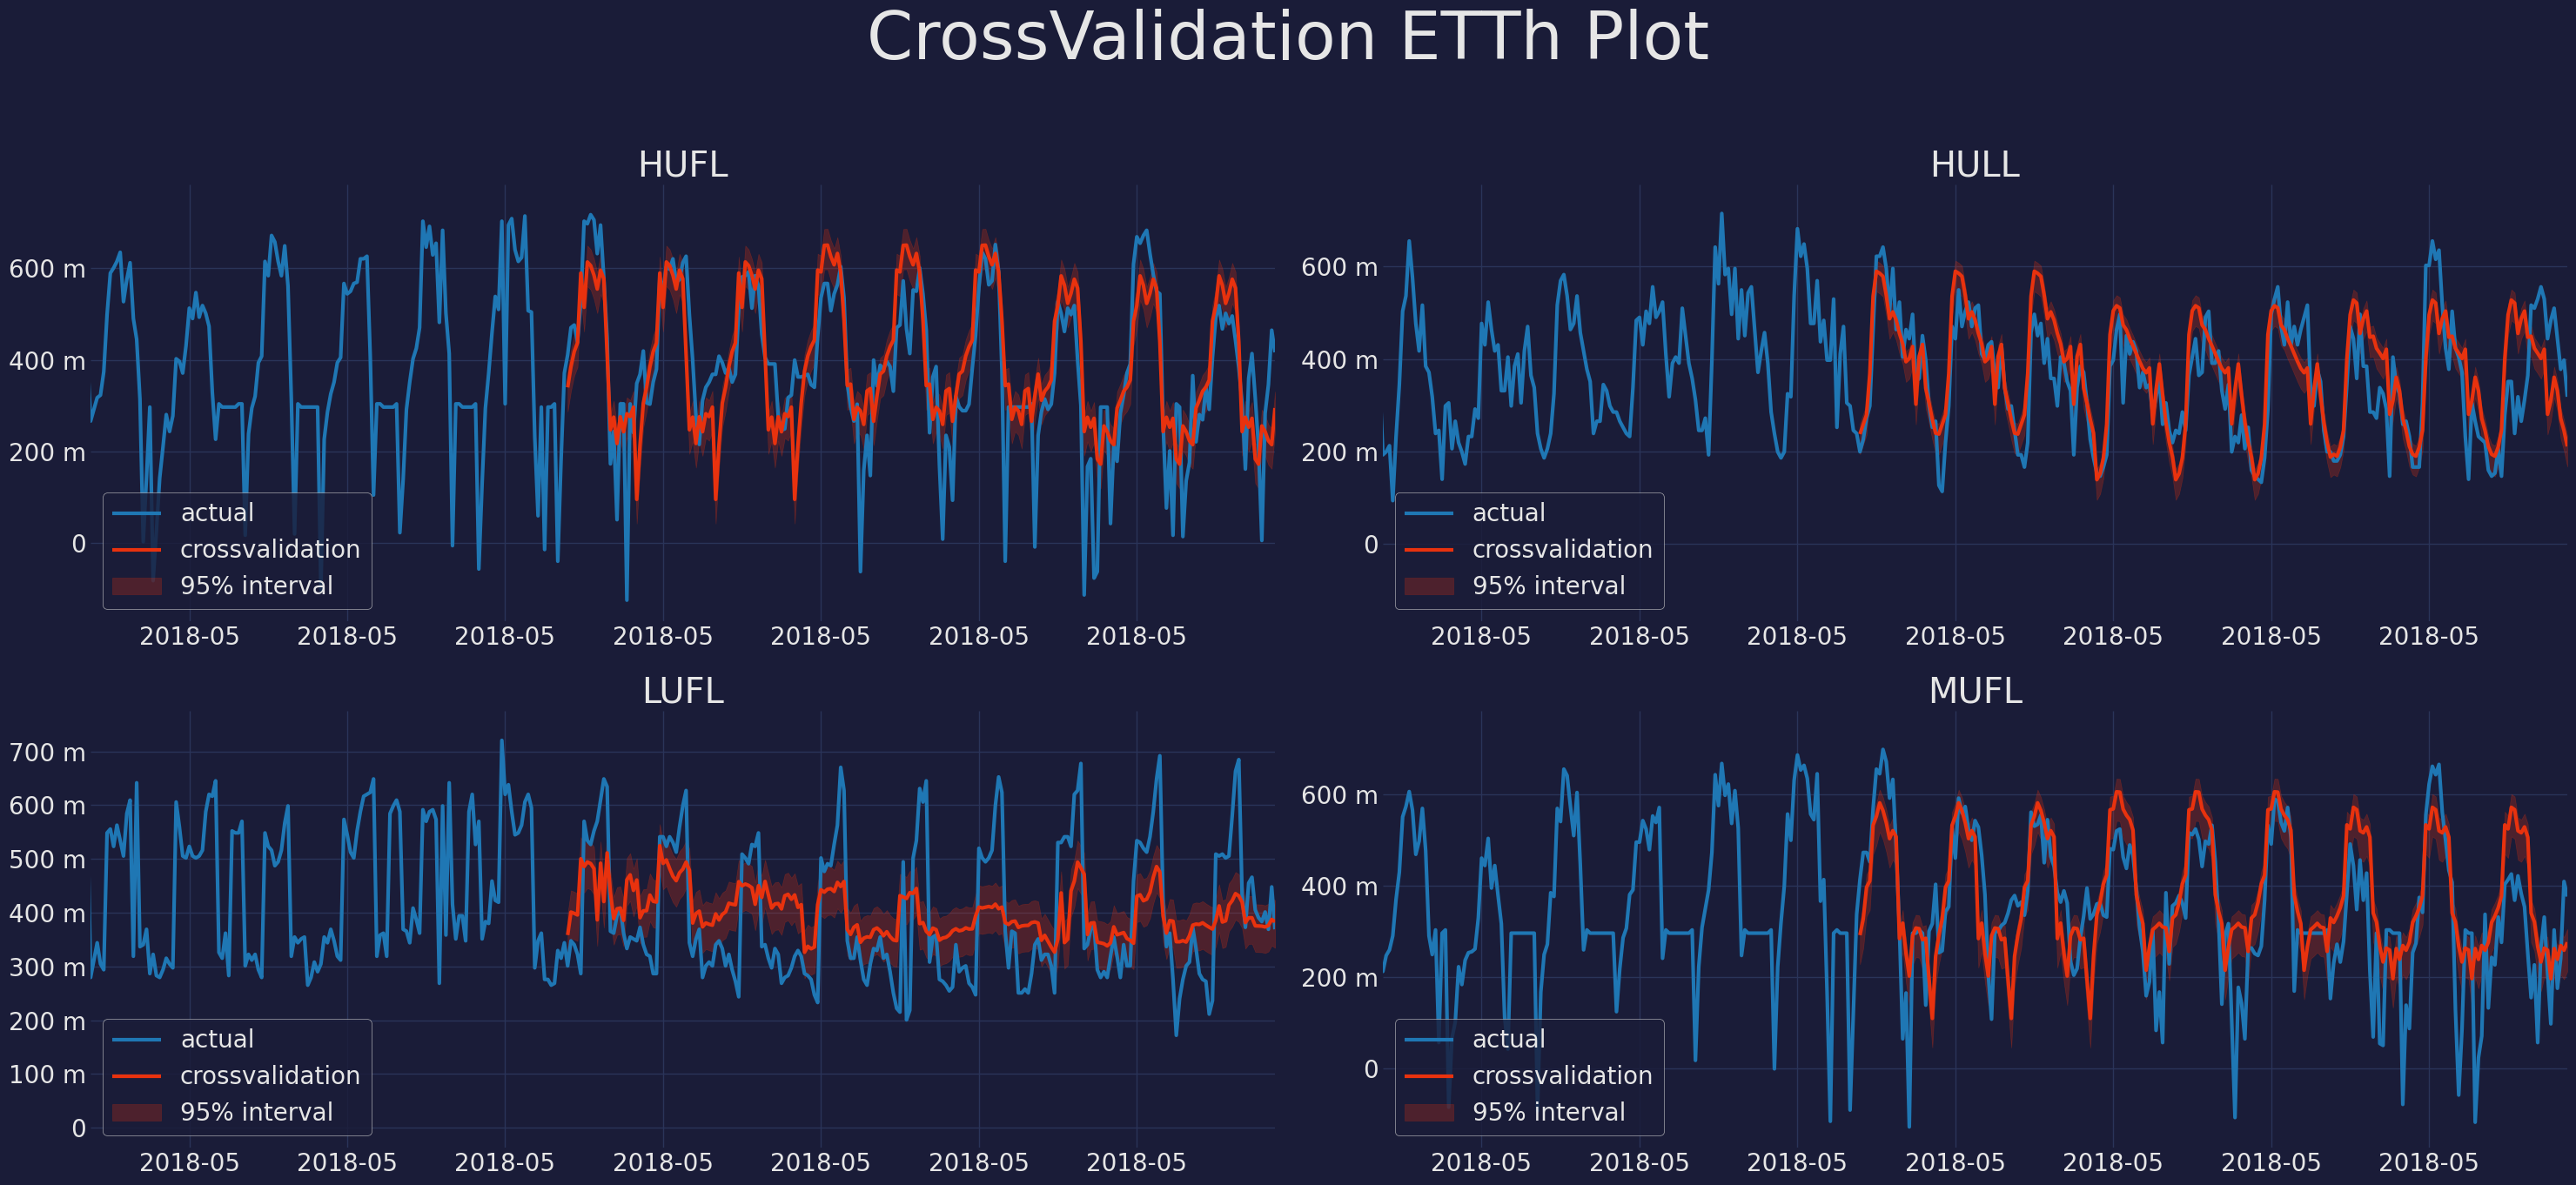

In [6]:
sflab.best_results_plots(horizon=72, result="crossval", actual=True, eval_horizon=1, unique_ids=cnsts.JCUIds)

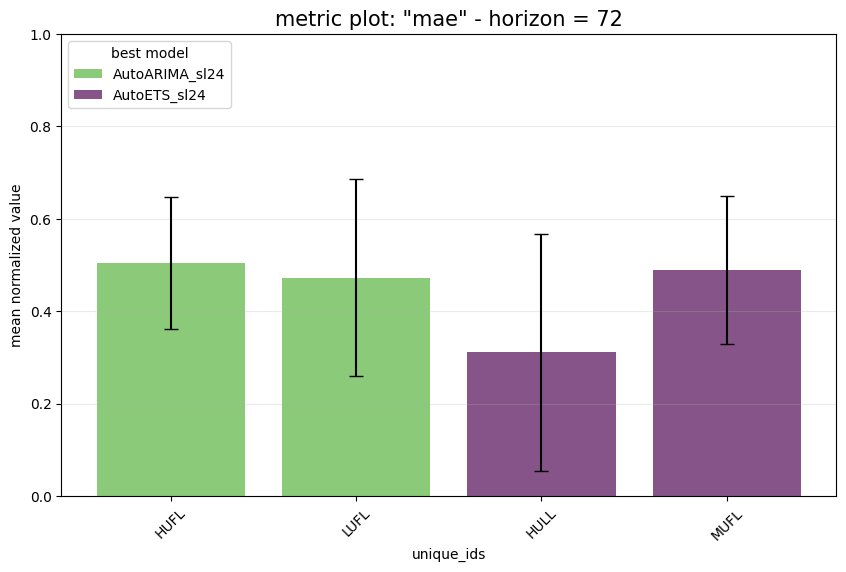

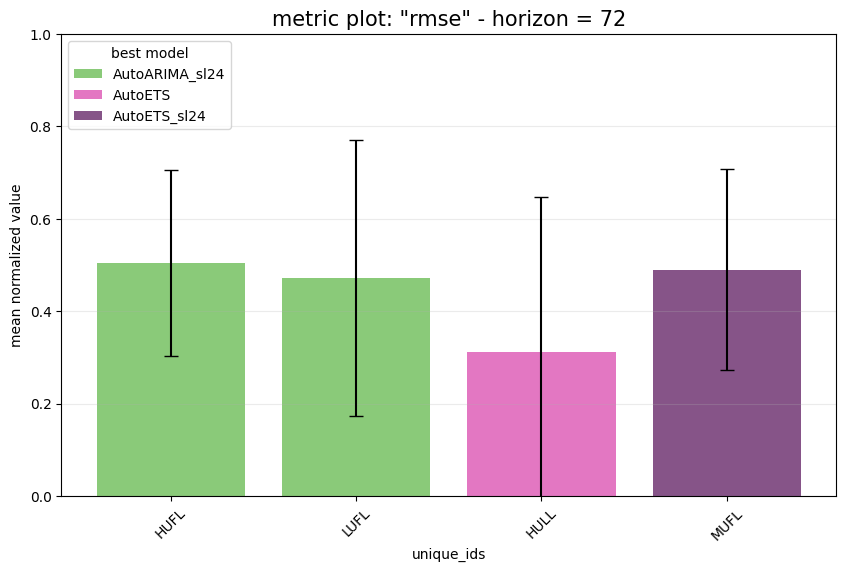

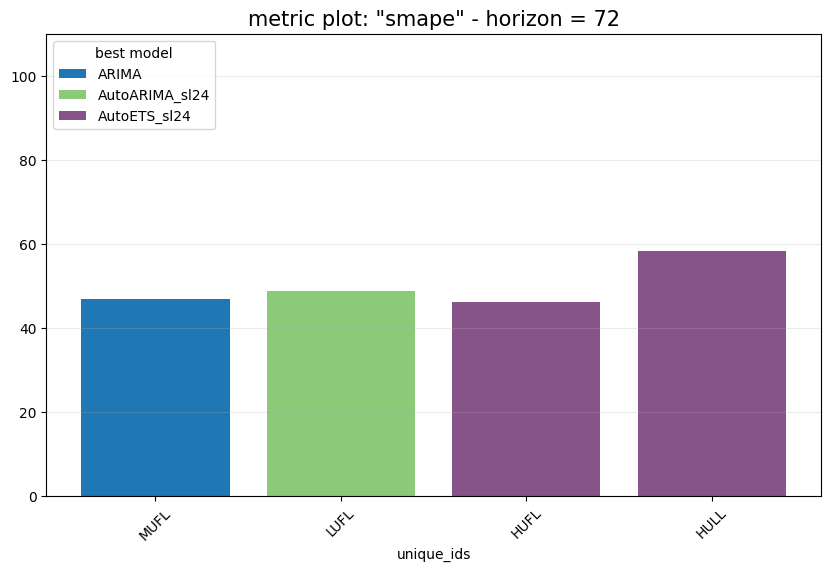

In [7]:
sflab.best_results_plots(horizon=72, result="metrics", unique_ids=cnsts.JCUIds)

In [8]:
sflab.best_results_metric_dataframe(result="crossval", unique_ids=cnsts.JCUIds)

,metric,unique_id,metric_value,best_model,transformation
0,mae,HUFL,0.088415,AutoETS_sl24,identity
1,mae,HULL,0.066790,AutoETS_sl24,identity
2,mae,LUFL,0.088679,AutoARIMA_sl24,identity
3,mae,MUFL,0.092515,AutoETS_sl24,identity


In [9]:
sflab.best_results_metric_dataframe(unique_ids=cnsts.JCUIds)


,metric,unique_id,metric_value,best_model,transformation
0,mae,HUFL,0.106057,AutoARIMA_sl24,identity
1,mae,HULL,0.188261,AutoETS_sl24,identity
2,mae,LUFL,0.157439,AutoARIMA_sl24,identity
3,mae,MUFL,0.118741,AutoETS_sl24,identity


In [10]:
sflab.best_results_summary(result="crossval")

,transformation,horizon,mean_mae
0,identity,72,0.056146
1,identity,48,0.053246
2,identity,24,0.052263
